## F1 Telemetry Analysis: Elite vs. Midfield Drivers


In [1]:
%pip install fastf1 pandas numpy matplotlib seaborn pyarrow


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Install fastf1 if not already installed
%pip install fastf1 pandas numpy matplotlib seaborn

import fastf1
import fastf1.plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib for FastF1
fastf1.plotting.setup_mpl(misc_mpl_mods=False)


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fastf1/plotting/_plotting.py:57: FutureWarning: The `misc_mpl_mods` argument was dropped from `.setup_mpl()` in version 3.6.0 and has no effect anymore. It will be removed in a future version of FastF1.
  warnings.warn(


In [3]:
# Configure Cache
import os

# Create a cache directory if it doesn't exist
cache_dir = 'fastf1_cache'
if not os.path.exists(cache_dir):
    os.makedirs(cache_dir)

fastf1.Cache.enable_cache(cache_dir)
print(f"Cache enabled at {cache_dir}")

Cache enabled at fastf1_cache


In [4]:
# Define Dynamic Team Tiers
def get_driver_tier(team_name, year, gp):
    """
    Classifies a team as 'Elite' or 'Midfield' based on the specific race context.
    Handles mid-season performance shifts (McLaren, Aston Martin).
    """
    # Standard Elite Teams (Consistent across 2023-2024)
    if team_name in ['Red Bull Racing', 'Ferrari', 'Mercedes']:
        return 'Elite'
    
    # Dynamic: McLaren (Midfield early 2023 -> Elite late 2023/2024)
    if team_name == 'McLaren':
        if year == 2024:
            return 'Elite'
        if year == 2023:
            # Major upgrade came around Austria (Round 10) / Silverstone
            # Early races: Bahrain, Saudi, Aus, Baku, Miami, Monaco, Spain, Canada -> Midfield
            early_races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Azerbaijan', 'Miami', 'Monaco', 'Spain', 'Canada']
            if gp in early_races:
                return 'Midfield'
            return 'Elite' # Silverstone, Monza, etc.

    # Dynamic: Aston Martin (Elite early 2023 -> Midfield late 2023/2024)
    if team_name == 'Aston Martin':
        if year == 2023:
            # Strong start (Alonso podiums)
            # Bahrain, Saudi, Aus, Miami, Monaco -> Elite performance
            strong_races = ['Bahrain', 'Saudi Arabia', 'Australia', 'Miami', 'Monaco']
            if gp in strong_races:
                return 'Elite'
        return 'Midfield'

    # Default to Midfield for others 
    # (Williams, Haas, Alpine, Alfa Romeo/Sauber, AlphaTauri/RB)
    return 'Midfield'

print("Dynamic driver tier logic defined.")

Dynamic driver tier logic defined.


### Note on Driver Classification Logic
**To: Teammate**

**Why Team-Based Tiers?**
We use team performance as the primary filter to control for the dominant factor in F1: the car. Comparing a Williams driver directly to a Red Bull driver on raw lap time measures the car more than the driver. By grouping into "Elite" vs "Midfield" machinery, we can look for outliers (e.g., a Midfield driver matching Elite braking profiles).

**Edge Cases & Dynamic Tiers:**
*   **McLaren (2023):** They started the season with a midfield car but introduced a major upgrade package (Austria/Silverstone) that made them elite contenders. We handle this by classifying them as "Midfield" for early 2023 races (Bahrain, Monaco) and "Elite" for late 2023/2024.
*   **Aston Martin (2023):** The opposite trend—podium contenders early in 2023, falling back later. We classify them as "Elite" for early 2023.

**Team Name Variations:**
*   *Alfa Romeo* is now *Kick Sauber* (or just Sauber).
*   *AlphaTauri* is now *RB* (Visa Cash App RB).
*   The code handles these by mapping the specific names found in the 2023-2024 data.

In [5]:
# Select Representative Races
# We select a mix of track types to get a robust classification
races_to_analyze = [
    (2023, 'Bahrain'),      # Balanced / Traction
    (2023, 'Silverstone'),  # High Speed Cornering
    (2023, 'Monza'),        # Low Downforce / Speed
    (2023, 'Monaco'),       # Street / High Downforce
]

print(f"Selected {len(races_to_analyze)} representative races.")

Selected 4 representative races.


In [6]:
# Extract Data from Multiple Races
all_fastest_laps = []
telemetry_data = [] # Store telemetry for later aggregate analysis

for year, gp in races_to_analyze:
    print(f"Processing {gp} {year}...")
    try:
        session = fastf1.get_session(year, gp, 'Q')
        session.load()
        
        # Calculate Pole for this race
        pole_lap = session.laps.pick_fastest()
        pole_time = pole_lap['LapTime']
        
        drivers = pd.unique(session.laps['Driver'])
        
        for drv in drivers:
            # Pick fastest lap for driver
            drv_lap = session.laps.pick_driver(drv).pick_fastest()
            
            # Check 1: Valid Lap Time
            if pd.isna(drv_lap['LapTime']) or drv_lap['LapTime'].total_seconds() == 0:
                continue

            # Basic Metrics
            gap = (drv_lap['LapTime'] - pole_time).total_seconds()
            
            # --- UPDATED TIER CALL ---
            tier = get_driver_tier(drv_lap['Team'], year, gp)
            # -------------------------
            
            # Store Lap Info
            lap_info = {
                'Driver': drv,
                'Team': drv_lap['Team'],
                'Tier': tier,
                'GP': gp,
                'Year': year,
                'LapTimeDeltaSeconds': gap,
                'SpeedST': drv_lap['SpeedST'] # Speed Trap
            }
            
            # Get Telemetry
            t = drv_lap.get_telemetry()
            
            # Check 2: Valid Telemetry
            if t.empty:
                print(f"Warning: No telemetry for {drv} at {gp}")
                continue
                
            # Check 3: Clean Missing Values
            # We need Speed and Distance for our plots. Drop rows where these are missing.
            original_len = len(t)
            t = t.dropna(subset=['Speed', 'Distance', 'Throttle'])
            
            if len(t) < original_len * 0.9: # If we lost more than 10% of data, skip it
                print(f"Warning: Corrupted telemetry for {drv} at {gp} (too many missing values)")
                continue

            # Add metadata to telemetry
            t['Driver'] = drv
            t['Tier'] = tier
            t['GP'] = gp
            
            # Append valid data
            all_fastest_laps.append(lap_info)
            telemetry_data.append(t)
                
    except Exception as e:
        print(f"Error with {gp}: {e}")

df_laps = pd.DataFrame(all_fastest_laps)
print(f"Collected {len(df_laps)} laps across {len(races_to_analyze)} races.")

Processing Bahrain 2023...


core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

Processing Silverstone 2023...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

Processing Monza 2023...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

Processing Monaco 2023...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

Collected 80 laps across 4 races.


## Checkpoint: Save Processed Data


In [7]:
# Save Laps Data (Metrics)
if 'df_laps' not in locals() or df_laps.empty:
    print("Error: 'df_laps' is empty or not defined. Please run the 'Extract Data' cell above first.")
else:
    df_laps.to_csv('processed_laps.csv', index=False)
    print("Saved processed_laps.csv")

# Save Telemetry Data (High frequency)
if 'telemetry_data' not in locals() or not telemetry_data:
    print("Warning: 'telemetry_data' is empty or not defined. Run the extraction cell first.")
else:
    try:
        print("Concatenating telemetry data (this may take a moment)...")
        all_telemetry = pd.concat(telemetry_data, ignore_index=True)
        
        # Try saving to Parquet (efficient)
        try:
            all_telemetry.to_parquet('processed_telemetry.parquet', index=False)
            print("Saved processed_telemetry.parquet")
        except Exception as e:
            print(f"Parquet save failed ({e}). Saving to CSV instead...")
            all_telemetry.to_csv('processed_telemetry.csv', index=False)
            print("Saved processed_telemetry.csv")
            
    except Exception as e:
        print(f"Error processing telemetry data: {e}")

Saved processed_laps.csv
Concatenating telemetry data (this may take a moment)...
Saved processed_telemetry.parquet


## Visualizations  

Average Gap to Pole by Tier (All Selected Races):
Tier
Elite       0.540031
Midfield    1.841854
Name: LapTimeDeltaSeconds, dtype: float64


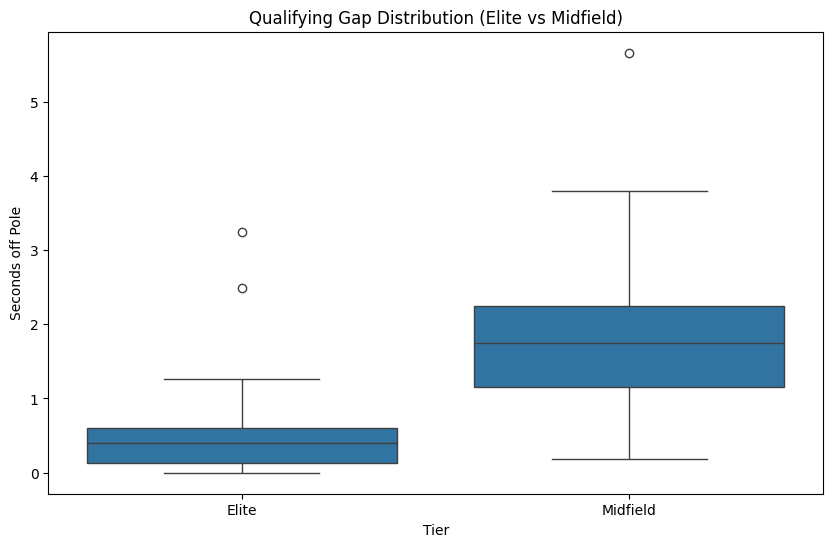

In [8]:
# Validate Classification (Aggregate)
print("Average Gap to Pole by Tier (All Selected Races):")
print(df_laps.groupby('Tier')['LapTimeDeltaSeconds'].mean())

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_laps, x='Tier', y='LapTimeDeltaSeconds')
plt.title('Qualifying Gap Distribution (Elite vs Midfield)')
plt.ylabel('Seconds off Pole')
plt.show()

Visualizing Speed Trace for Monaco
Comparing VER (Elite) vs OCO (Midfield)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fastf1/core.py:3081: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


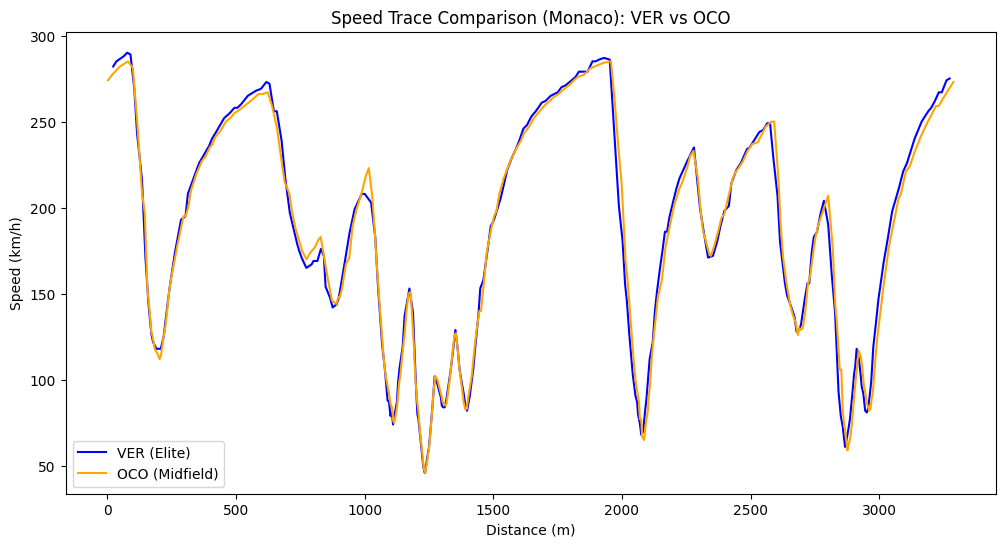

In [9]:
# Visualize Speed Traces: Elite vs. Midfield (Example from last processed race)
# We use the 'session' object which holds the data for the last race in the loop
current_gp = races_to_analyze[-1][1]
print(f"Visualizing Speed Trace for {current_gp}")

# Pick one Elite and one Midfield driver present in this session
# We filter df_laps for the current GP to find valid drivers
current_laps = df_laps[df_laps['GP'] == current_gp]
elite_driver = current_laps[current_laps['Tier'] == 'Elite'].iloc[0]['Driver']
midfield_driver = current_laps[current_laps['Tier'] == 'Midfield'].iloc[0]['Driver']

print(f"Comparing {elite_driver} (Elite) vs {midfield_driver} (Midfield)")

lap_elite = session.laps.pick_driver(elite_driver).pick_fastest()
lap_mid = session.laps.pick_driver(midfield_driver).pick_fastest()

tel_elite = lap_elite.get_car_data().add_distance()
tel_mid = lap_mid.get_car_data().add_distance()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(tel_elite['Distance'], tel_elite['Speed'], label=f'{elite_driver} (Elite)', color='blue')
ax.plot(tel_mid['Distance'], tel_mid['Speed'], label=f'{midfield_driver} (Midfield)', color='orange')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Speed (km/h)')
ax.set_title(f'Speed Trace Comparison ({current_gp}): {elite_driver} vs {midfield_driver}')
ax.legend()
plt.show()

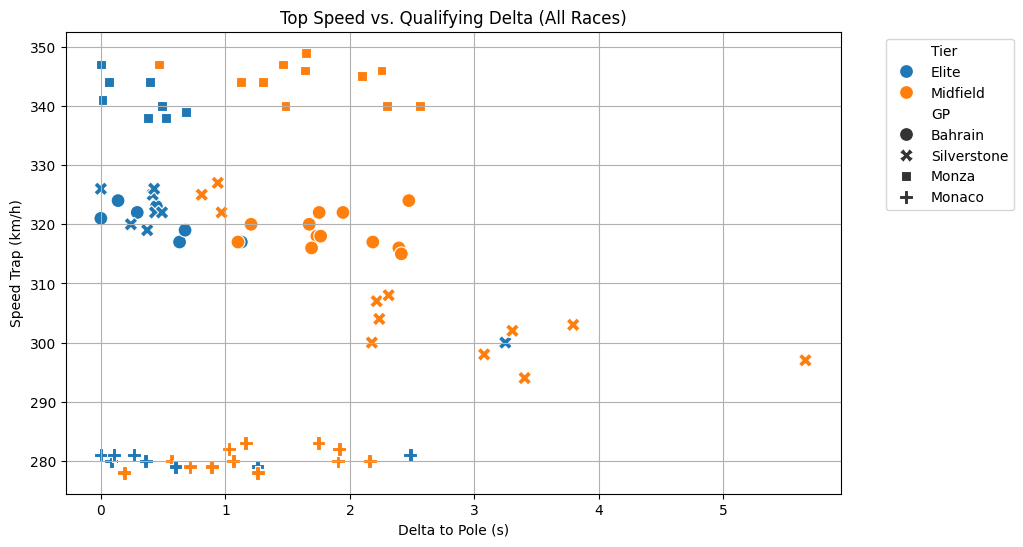

In [10]:
# Analyze Braking Points vs. Lap Time Delta
# Using aggregated data from all races

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_laps, x='LapTimeDeltaSeconds', y='SpeedST', hue='Tier', style='GP', s=100)
plt.title('Top Speed vs. Qualifying Delta (All Races)')
plt.xlabel('Delta to Pole (s)')
plt.ylabel('Speed Trap (km/h)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

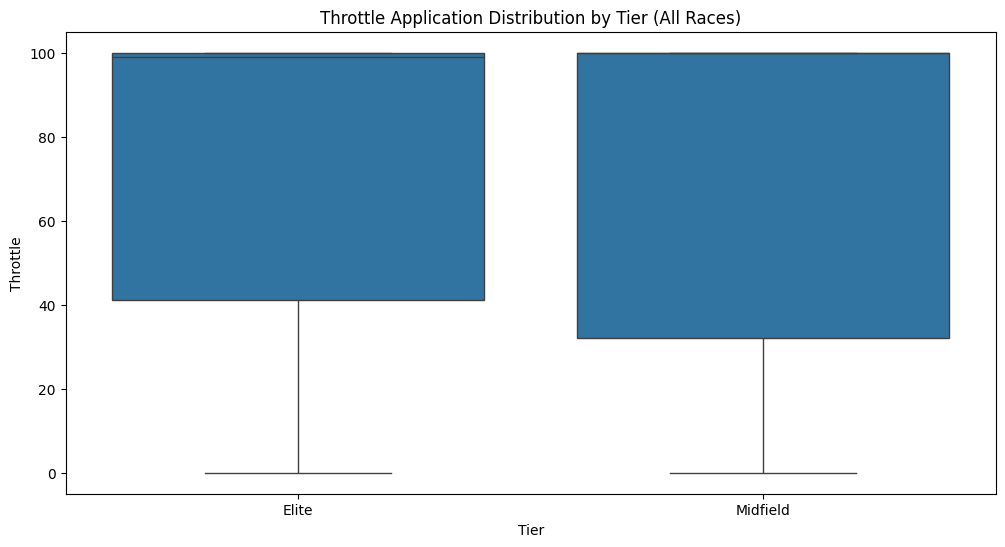

In [11]:
# Compare Throttle Application Consistency
# Using collected telemetry from all races
all_throttle = pd.concat(telemetry_data)

# Filter for a cleaner plot (optional: just one GP or all)
# Plotting all might be crowded, let's plot distribution by Tier
plt.figure(figsize=(12, 6))
sns.boxplot(data=all_throttle, x='Tier', y='Throttle', showfliers=False)
plt.title('Throttle Application Distribution by Tier (All Races)')
plt.show()

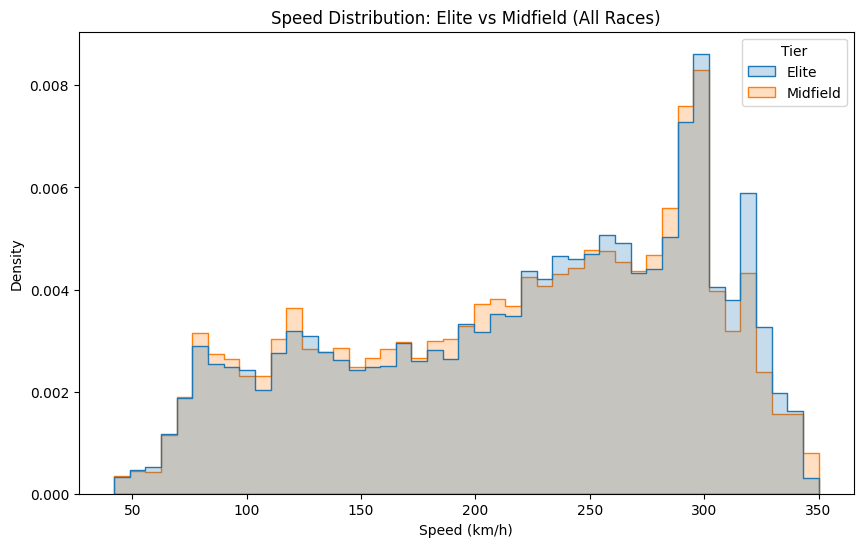

In [12]:
# Cornering Speed Heatmaps (Simplified)
# Using collected telemetry from all races
# We reuse 'all_throttle' since it contains the full telemetry (Speed, Throttle, etc.)

plt.figure(figsize=(10, 6))
sns.histplot(data=all_throttle, x='Speed', hue='Tier', element='step', stat='density', common_norm=False)
plt.title('Speed Distribution: Elite vs Midfield (All Races)')
plt.xlabel('Speed (km/h)')
plt.show()